In [1]:
%pip install scikit-learn==1.4.2


[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
import math
from sklearn.model_selection import train_test_split

In [3]:
db = pd.read_csv('game_data_all.csv')

In [4]:
db.head()

,serial number,game,link,release,peak_players,positive_reviews,negative_reviews,total_reviews,rating,primary_genre,store_genres,publisher,developer,detected_technologies,store_asset_mod_time,review_percentage,players_right_now,24_hour_peak,all_time_peak,all_time_peak_date
0,0,Pizza Tower,/app/2231450/,1/26/23,4529,19807,227,20034,96.39,Action (1),"Action (1), Indie (23)",Tour De Pizza,Tour De Pizza,Engine.GameMaker; SDK.FMOD,1/10/23,98.0,"3,101","3,606",4529,3/25/23
1,1,Resident Evil 4,/app/2050650/,3/24/23,168191,61752,1616,63368,95.75,Action (1),"Action (1), Adventure (25)",CAPCOM Co. Ltd.,CAPCOM Co. Ltd.,Engine.RE_Engine; SDK.AMD_GPU_Services,3/29/23,97.0,"46,289","47,164",168191,3/25/23
2,2,The Murder of Sonic the Hedgehog,/app/2324650/,3/31/23,15543,12643,213,12856,95.54,Casual (4),"Casual (4), Free to Play (37), Indie (23), Sim...",SEGA,SEGA,Engine.Unity; SDK.UnityBurst; SDK.cURL,3/24/23,98.0,618,776,15543,3/31/23
3,3,Pineapple on pizza,/app/2263010/,3/28/23,1415,11717,209,11926,95.39,Indie (23),"Casual (4), Free to Play (37), Indie (23)",Majorariatto,Majorariatto,Engine.Unity; SDK.cURL,3/22/23,98.0,101,101,1415,3/28/23
4,4,Hi-Fi RUSH,/app/1817230/,1/25/23,6132,14152,324,14476,95.09,Action (1),Action (1),Bethesda Softworks,Tango Gameworks,Engine.Unreal; SDK.Intel_OID; SDK.Intel_XeSS; ...,4/11/23,97.0,630,664,6132,1/29/23


In [5]:
db.shape

(67571, 20)

In [6]:
db.count()

serial number            67571
game                     67571
link                     67571
release                  67571
peak_players             67571
positive_reviews         67571
negative_reviews         67571
total_reviews            67571
rating                   67571
primary_genre            67561
store_genres             67514
publisher                67129
developer                67445
detected_technologies    60265
store_asset_mod_time     67275
review_percentage        47767
players_right_now        67565
24_hour_peak             67565
all_time_peak            67571
all_time_peak_date       67565
dtype: int64

In [7]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67571 entries, 0 to 67570
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   serial number          67571 non-null  int64  
 1   game                   67571 non-null  object 
 2   link                   67571 non-null  object 
 3   release                67571 non-null  object 
 4   peak_players           67571 non-null  int64  
 5   positive_reviews       67571 non-null  int64  
 6   negative_reviews       67571 non-null  int64  
 7   total_reviews          67571 non-null  int64  
 8   rating                 67571 non-null  float64
 9   primary_genre          67561 non-null  object 
 10  store_genres           67514 non-null  object 
 11  publisher              67129 non-null  object 
 12  developer              67445 non-null  object 
 13  detected_technologies  60265 non-null  object 
 14  store_asset_mod_time   67275 non-null  object 
 15  re

# Cleaning Steps

### 1)Dropping unnecessary columns

In [8]:
column_to_drop = ['serial number','link']
db.drop(column_to_drop,axis=1,inplace = True)

In [9]:
db.head()

,game,release,peak_players,positive_reviews,negative_reviews,total_reviews,rating,primary_genre,store_genres,publisher,developer,detected_technologies,store_asset_mod_time,review_percentage,players_right_now,24_hour_peak,all_time_peak,all_time_peak_date
0,Pizza Tower,1/26/23,4529,19807,227,20034,96.39,Action (1),"Action (1), Indie (23)",Tour De Pizza,Tour De Pizza,Engine.GameMaker; SDK.FMOD,1/10/23,98.0,"3,101","3,606",4529,3/25/23
1,Resident Evil 4,3/24/23,168191,61752,1616,63368,95.75,Action (1),"Action (1), Adventure (25)",CAPCOM Co. Ltd.,CAPCOM Co. Ltd.,Engine.RE_Engine; SDK.AMD_GPU_Services,3/29/23,97.0,"46,289","47,164",168191,3/25/23
2,The Murder of Sonic the Hedgehog,3/31/23,15543,12643,213,12856,95.54,Casual (4),"Casual (4), Free to Play (37), Indie (23), Sim...",SEGA,SEGA,Engine.Unity; SDK.UnityBurst; SDK.cURL,3/24/23,98.0,618,776,15543,3/31/23
3,Pineapple on pizza,3/28/23,1415,11717,209,11926,95.39,Indie (23),"Casual (4), Free to Play (37), Indie (23)",Majorariatto,Majorariatto,Engine.Unity; SDK.cURL,3/22/23,98.0,101,101,1415,3/28/23
4,Hi-Fi RUSH,1/25/23,6132,14152,324,14476,95.09,Action (1),Action (1),Bethesda Softworks,Tango Gameworks,Engine.Unreal; SDK.Intel_OID; SDK.Intel_XeSS; ...,4/11/23,97.0,630,664,6132,1/29/23


### 2) Dropping Missing Values

In [10]:
#return missing values in every column
db.isna() .sum()

game                         0
release                      0
peak_players                 0
positive_reviews             0
negative_reviews             0
total_reviews                0
rating                       0
primary_genre               10
store_genres                57
publisher                  442
developer                  126
detected_technologies     7306
store_asset_mod_time       296
review_percentage        19804
players_right_now            6
24_hour_peak                 6
all_time_peak                0
all_time_peak_date           6
dtype: int64

In [11]:
#dropping null values in this column as it is our target variable
db.dropna(subset=['detected_technologies'], inplace= True)

In [12]:
db.isna().sum()

game                         0
release                      0
peak_players                 0
positive_reviews             0
negative_reviews             0
total_reviews                0
rating                       0
primary_genre               10
store_genres                52
publisher                  397
developer                  103
detected_technologies        0
store_asset_mod_time       230
review_percentage        17060
players_right_now            1
24_hour_peak                 1
all_time_peak                0
all_time_peak_date           1
dtype: int64

### 3)Handling Missing values

In [13]:
#Assigning ranodom values for these columns as they are not out target variable
string_columns = ['primary_genre','store_genres','publisher','developer']

for column in string_columns:
    non_missing_values = db[column].dropna()
    random_sample = np.random.choice(non_missing_values, db[column].isnull().sum())
    db.loc[db[column].isnull(), column] = random_sample

In [14]:
db.isna().sum()

game                         0
release                      0
peak_players                 0
positive_reviews             0
negative_reviews             0
total_reviews                0
rating                       0
primary_genre                0
store_genres                 0
publisher                    0
developer                    0
detected_technologies        0
store_asset_mod_time       230
review_percentage        17060
players_right_now            1
24_hour_peak                 1
all_time_peak                0
all_time_peak_date           1
dtype: int64

In [15]:
#getting numerical and categorical columns
numerical_columns = db.select_dtypes(include=['number']).columns
categorical_columns = db.select_dtypes(include=['object']).columns
numerical_columns , categorical_columns

(Index(['peak_players', 'positive_reviews', 'negative_reviews', 'total_reviews',
        'rating', 'review_percentage', 'all_time_peak'],
       dtype='object'),
 Index(['game', 'release', 'primary_genre', 'store_genres', 'publisher',
        'developer', 'detected_technologies', 'store_asset_mod_time',
        'players_right_now', '24_hour_peak', 'all_time_peak_date'],
       dtype='object'))

In [16]:
#imputing numerical data with mean and categorical values with mode

In [17]:
db[numerical_columns] = db[numerical_columns].fillna(db[numerical_columns].mean())
for column in categorical_columns:
    db[column].fillna(db[column].mode()[0], inplace = True)


In [18]:
db.isna().sum()

game                     0
release                  0
peak_players             0
positive_reviews         0
negative_reviews         0
total_reviews            0
rating                   0
primary_genre            0
store_genres             0
publisher                0
developer                0
detected_technologies    0
store_asset_mod_time     0
review_percentage        0
players_right_now        0
24_hour_peak             0
all_time_peak            0
all_time_peak_date       0
dtype: int64

### 4) Case Standardization

In [19]:
string_columns = ['game','primary_genre','store_genres','publisher','developer','detected_technologies']
for column in string_columns:
    db[column] = db[column].str.lower()

In [20]:
db.head()

,game,release,peak_players,positive_reviews,negative_reviews,total_reviews,rating,primary_genre,store_genres,publisher,developer,detected_technologies,store_asset_mod_time,review_percentage,players_right_now,24_hour_peak,all_time_peak,all_time_peak_date
0,pizza tower,1/26/23,4529,19807,227,20034,96.39,action (1),"action (1), indie (23)",tour de pizza,tour de pizza,engine.gamemaker; sdk.fmod,1/10/23,98.0,"3,101","3,606",4529,3/25/23
1,resident evil 4,3/24/23,168191,61752,1616,63368,95.75,action (1),"action (1), adventure (25)",capcom co. ltd.,capcom co. ltd.,engine.re_engine; sdk.amd_gpu_services,3/29/23,97.0,"46,289","47,164",168191,3/25/23
2,the murder of sonic the hedgehog,3/31/23,15543,12643,213,12856,95.54,casual (4),"casual (4), free to play (37), indie (23), sim...",sega,sega,engine.unity; sdk.unityburst; sdk.curl,3/24/23,98.0,618,776,15543,3/31/23
3,pineapple on pizza,3/28/23,1415,11717,209,11926,95.39,indie (23),"casual (4), free to play (37), indie (23)",majorariatto,majorariatto,engine.unity; sdk.curl,3/22/23,98.0,101,101,1415,3/28/23
4,hi-fi rush,1/25/23,6132,14152,324,14476,95.09,action (1),action (1),bethesda softworks,tango gameworks,engine.unreal; sdk.intel_oid; sdk.intel_xess; ...,4/11/23,97.0,630,664,6132,1/29/23


### 5) Data type checking

In [21]:
db.dtypes

game                      object
release                   object
peak_players               int64
positive_reviews           int64
negative_reviews           int64
total_reviews              int64
rating                   float64
primary_genre             object
store_genres              object
publisher                 object
developer                 object
detected_technologies     object
store_asset_mod_time      object
review_percentage        float64
players_right_now         object
24_hour_peak              object
all_time_peak              int64
all_time_peak_date        object
dtype: object

In [22]:
columns = ['players_right_now','24_hour_peak']
db[columns] = db[columns].replace(',', '', regex=True).astype(int)

In [23]:
columns = ['release','store_asset_mod_time','all_time_peak_date']
db[columns] = db[columns].apply(pd.to_datetime, errors='coerce')

In [24]:
db.dtypes

game                             object
release                  datetime64[ns]
peak_players                      int64
positive_reviews                  int64
negative_reviews                  int64
total_reviews                     int64
rating                          float64
primary_genre                    object
store_genres                     object
publisher                        object
developer                        object
detected_technologies            object
store_asset_mod_time     datetime64[ns]
review_percentage               float64
players_right_now                 int64
24_hour_peak                      int64
all_time_peak                     int64
all_time_peak_date       datetime64[ns]
dtype: object

### 6) Cleaning Text columns

In [25]:
import re
text_columns = ['game','primary_genre','store_genres','publisher','developer','detected_technologies']
for column in text_columns:
    db[column] = db[column].apply(lambda x: re.sub('[^a-zA-Z]', ' ', x))

In [26]:
db

,game,release,peak_players,positive_reviews,negative_reviews,total_reviews,rating,primary_genre,store_genres,publisher,developer,detected_technologies,store_asset_mod_time,review_percentage,players_right_now,24_hour_peak,all_time_peak,all_time_peak_date
0,pizza tower,2023-01-26,4529,19807,227,20034,96.39,action,action indie,tour de pizza,tour de pizza,engine gamemaker sdk fmod,2023-01-10,98.0,3101,3606,4529,2023-03-25
1,resident evil,2023-03-24,168191,61752,1616,63368,95.75,action,action adventure,capcom co ltd,capcom co ltd,engine re engine sdk amd gpu services,2023-03-29,97.0,46289,47164,168191,2023-03-25
2,the murder of sonic the hedgehog,2023-03-31,15543,12643,213,12856,95.54,casual,casual free to play indie sim...,sega,sega,engine unity sdk unityburst sdk curl,2023-03-24,98.0,618,776,15543,2023-03-31
3,pineapple on pizza,2023-03-28,1415,11717,209,11926,95.39,indie,casual free to play indie,majorariatto,majorariatto,engine unity sdk curl,2023-03-22,98.0,101,101,1415,2023-03-28
4,hi fi rush,2023-01-25,6132,14152,324,14476,95.09,action,action,bethesda softworks,tango gameworks,engine unreal sdk intel oid sdk intel xess ...,2023-04-11,97.0,630,664,6132,2023-01-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67564,earth,2006-04-01,9960,878,375,1253,67.73,strategy,strategy,topware interactive,reality pump studios,engine fna engine xna sdk openal,2019-12-23,70.0,13,17,9960,2018-04-12
67565,roboblitz,2006-11-07,7,57,20,77,67.55,action,action indie,naked sky entertainment,naked sky entertainment,engine unreal sdk openal sdk vorbis,2022-10-29,75.0,0,1,7,2014-04-27
67568,gumboy crazy adventures,2006-12-19,22,61,60,121,50.32,unknown genre,casual indie,cinemax s r o,cinemax s r o,sdk openal sdk vorbis,2022-11-04,50.0,0,1,22,2008-09-13
67569,shattered union,2006-10-25,13,71,70,141,50.27,strategy,strategy,k,poptop,sdk bink video sdk miles sound system,2019-09-20,50.0,1,2,13,2020-03-15


### 7) Normalization

In [27]:
columns_to_normalize = ['rating','review_percentage']
normalised_data = db.copy()
for column in columns_to_normalize:
     normalised_data[column] = (normalised_data[column] - normalised_data[column].min()) / (normalised_data[column].max() - normalised_data[column].min())

In [28]:
normalised_data.head()

,game,release,peak_players,positive_reviews,negative_reviews,total_reviews,rating,primary_genre,store_genres,publisher,developer,detected_technologies,store_asset_mod_time,review_percentage,players_right_now,24_hour_peak,all_time_peak,all_time_peak_date
0,pizza tower,2023-01-26,4529,19807,227,20034,0.986052,action,action indie,tour de pizza,tour de pizza,engine gamemaker sdk fmod,2023-01-10,0.98,3101,3606,4529,2023-03-25
1,resident evil,2023-03-24,168191,61752,1616,63368,0.978290,action,action adventure,capcom co ltd,capcom co ltd,engine re engine sdk amd gpu services,2023-03-29,0.97,46289,47164,168191,2023-03-25
2,the murder of sonic the hedgehog,2023-03-31,15543,12643,213,12856,0.975743,casual,casual free to play indie sim...,sega,sega,engine unity sdk unityburst sdk curl,2023-03-24,0.98,618,776,15543,2023-03-31
3,pineapple on pizza,2023-03-28,1415,11717,209,11926,0.973924,indie,casual free to play indie,majorariatto,majorariatto,engine unity sdk curl,2023-03-22,0.98,101,101,1415,2023-03-28
4,hi fi rush,2023-01-25,6132,14152,324,14476,0.970285,action,action,bethesda softworks,tango gameworks,engine unreal sdk intel oid sdk intel xess ...,2023-04-11,0.97,630,664,6132,2023-01-29


### 8) Setting precision

In [29]:
columns_to_set_precision = ['rating']
normalised_data[columns_to_set_precision] = normalised_data[columns_to_set_precision].round(3)

In [30]:
normalised_data.head()

,game,release,peak_players,positive_reviews,negative_reviews,total_reviews,rating,primary_genre,store_genres,publisher,developer,detected_technologies,store_asset_mod_time,review_percentage,players_right_now,24_hour_peak,all_time_peak,all_time_peak_date
0,pizza tower,2023-01-26,4529,19807,227,20034,0.986,action,action indie,tour de pizza,tour de pizza,engine gamemaker sdk fmod,2023-01-10,0.98,3101,3606,4529,2023-03-25
1,resident evil,2023-03-24,168191,61752,1616,63368,0.978,action,action adventure,capcom co ltd,capcom co ltd,engine re engine sdk amd gpu services,2023-03-29,0.97,46289,47164,168191,2023-03-25
2,the murder of sonic the hedgehog,2023-03-31,15543,12643,213,12856,0.976,casual,casual free to play indie sim...,sega,sega,engine unity sdk unityburst sdk curl,2023-03-24,0.98,618,776,15543,2023-03-31
3,pineapple on pizza,2023-03-28,1415,11717,209,11926,0.974,indie,casual free to play indie,majorariatto,majorariatto,engine unity sdk curl,2023-03-22,0.98,101,101,1415,2023-03-28
4,hi fi rush,2023-01-25,6132,14152,324,14476,0.970,action,action,bethesda softworks,tango gameworks,engine unreal sdk intel oid sdk intel xess ...,2023-04-11,0.97,630,664,6132,2023-01-29


### 9) One-hot Encoding

In [31]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Assuming 'db' is your DataFrame
db_encoded = db.copy()

# Splitting the string by ';' and converting to list
db_encoded['detected_technologies'] = db_encoded['detected_technologies'].apply(lambda x: x.split(';') if isinstance(x, str) else [])

# Counting occurrences of each technology
technology_counts = {}
for tech_list in db_encoded['detected_technologies']:
    for tech in tech_list:
        if tech in technology_counts:
            technology_counts[tech] += 1
        else:
            technology_counts[tech] = 1

# Selecting top 10 frequent technologies
top_10_technologies = sorted(technology_counts, key=technology_counts.get, reverse=True)[:10]

# Filtering the technologies in the DataFrame
db_encoded['detected_technologies'] = db_encoded['detected_technologies'].apply(lambda x: [tech for tech in x if tech in top_10_technologies])

# Applying MultiLabelBinarizer
mlb = MultiLabelBinarizer()
technologies_ohe = mlb.fit_transform(db_encoded['detected_technologies'])
technologies_db = pd.DataFrame(technologies_ohe, columns=mlb.classes_)

# Concatenating the one-hot encoded columns
db_encoded = pd.concat([db_encoded.drop('detected_technologies', axis=1), technologies_db], axis=1)

# Dropping rows with NaN in the 'rating' column
db_encoded.dropna(subset=['rating'], inplace=True)

# Filling NaN values in float columns with median
float_columns = db_encoded.select_dtypes(include=['float64']).columns
db_encoded[float_columns] = db_encoded[float_columns].fillna(db_encoded[float_columns].median())



In [32]:
db_encoded

,game,release,peak_players,positive_reviews,negative_reviews,total_reviews,rating,primary_genre,store_genres,publisher,...,engine gamemaker,engine renpy sdk sdl,engine unity,engine unity sdk curl,engine unity sdk oculusxrplugin sdk openvr,engine unity sdk openvr,engine unity sdk photon,engine unity sdk steamworksnet sdk curl,engine unreal sdk nvidia apex sdk nvidia nsight aftermath sdk nvidia physx sdk oculusxrplugin sdk openvr sdk vorbis,sdk nwjs sdk nodejs
0,pizza tower,2023-01-26,4529.0,19807.0,227.0,20034.0,96.39,action,action indie,tour de pizza,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,resident evil,2023-03-24,168191.0,61752.0,1616.0,63368.0,95.75,action,action adventure,capcom co ltd,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,the murder of sonic the hedgehog,2023-03-31,15543.0,12643.0,213.0,12856.0,95.54,casual,casual free to play indie sim...,sega,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,pineapple on pizza,2023-03-28,1415.0,11717.0,209.0,11926.0,95.39,indie,casual free to play indie,majorariatto,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,hi fi rush,2023-01-25,6132.0,14152.0,324.0,14476.0,95.09,action,action,bethesda softworks,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67564,earth,2006-04-01,9960.0,878.0,375.0,1253.0,67.73,strategy,strategy,topware interactive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67565,roboblitz,2006-11-07,7.0,57.0,20.0,77.0,67.55,action,action indie,naked sky entertainment,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67568,gumboy crazy adventures,2006-12-19,22.0,61.0,60.0,121.0,50.32,unknown genre,casual indie,cinemax s r o,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67569,shattered union,2006-10-25,13.0,71.0,70.0,141.0,50.27,strategy,strategy,k,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
db_encoded.isna().sum()

game                                                                                                                         0
release                                                                                                                      0
peak_players                                                                                                                 0
positive_reviews                                                                                                             0
negative_reviews                                                                                                             0
total_reviews                                                                                                                0
rating                                                                                                                       0
primary_genre                                                                                                  

### 10) Outliers Removal

In [34]:
numerical_columns = db.select_dtypes(include=['int64', 'float64']).columns

# Convert all numerical columns to numeric, handling non-numeric values
for column in numerical_columns:
    db[column] = pd.to_numeric(db[column], errors='coerce')

# Define lower and upper quantile thresholds
lower_quantile = 0.05
upper_quantile = 0.95

# Remove outliers based on the quantile thresholds for each numerical column
for column in numerical_columns:
    lower_bound = db[column].quantile(lower_quantile)
    upper_bound = db[column].quantile(upper_quantile)
    db = db[(db[column] >= lower_bound) & (db[column] <= upper_bound)]

# Display the shape of the data after outlier removal
print(db.shape)

(32918, 18)


# Exploratory Data Analysis

### 1)Descriptive Statistics

In [35]:
summary_stats = db.describe()
print("\nSummary Statistics:")
print(summary_stats)


Summary Statistics:
       peak_players  positive_reviews  negative_reviews  total_reviews  \
count  32918.000000      32918.000000      32918.000000   32918.000000   
mean       9.461176         25.138982          7.951455      33.090437   
std       20.539857         35.646370         12.588834      46.041691   
min        1.000000          1.000000          0.000000       2.000000   
25%        2.000000          4.000000          1.000000       6.000000   
50%        4.000000         11.000000          3.000000      15.000000   
75%        9.000000         30.000000          9.000000      39.000000   
max     1504.000000        268.000000        106.000000     308.000000   

             rating  review_percentage  players_right_now  24_hour_peak  \
count  32918.000000       32918.000000       32918.000000  32918.000000   
mean      64.538685          75.232967           0.055988      0.474634   
std        9.089312           9.882052           0.255559      0.741701   
min       41

### 2) Univariate analysis

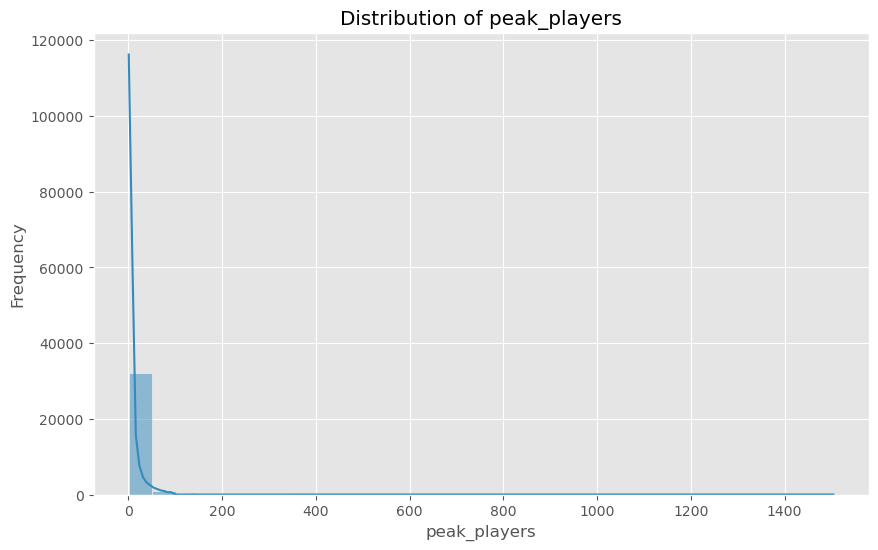

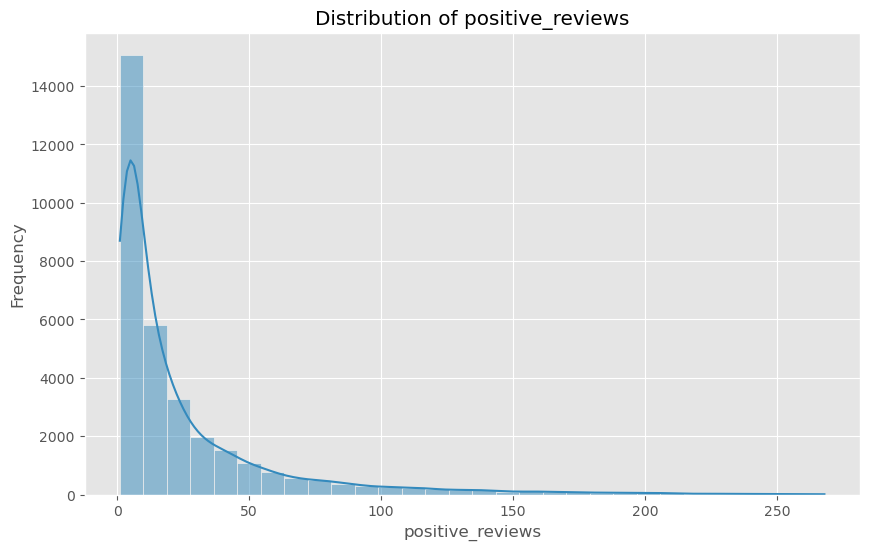

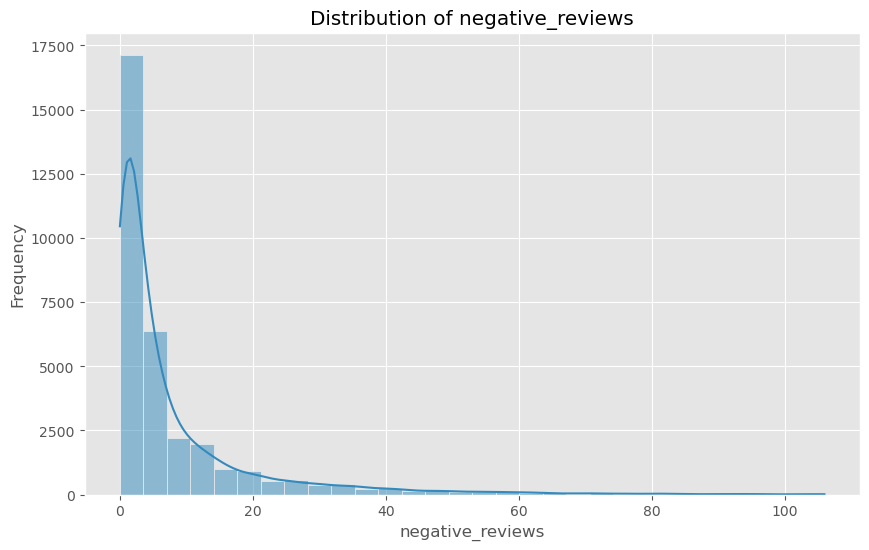

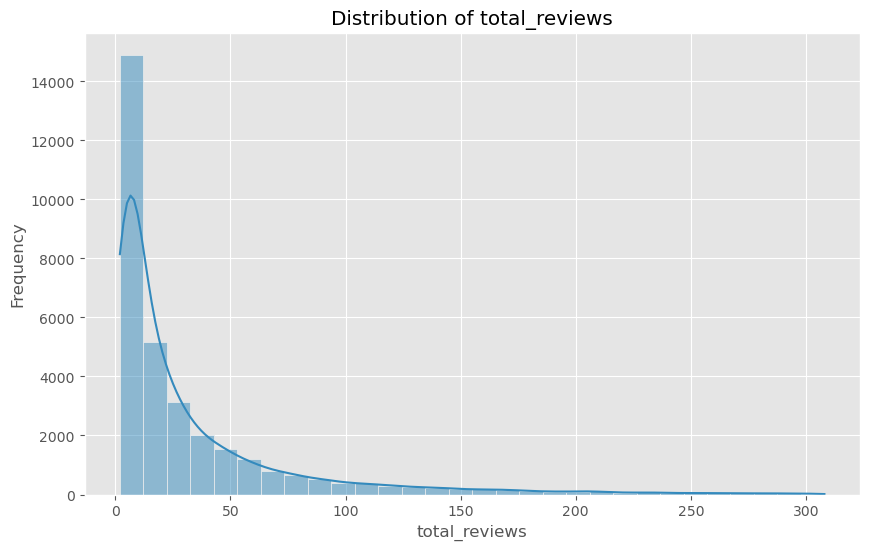

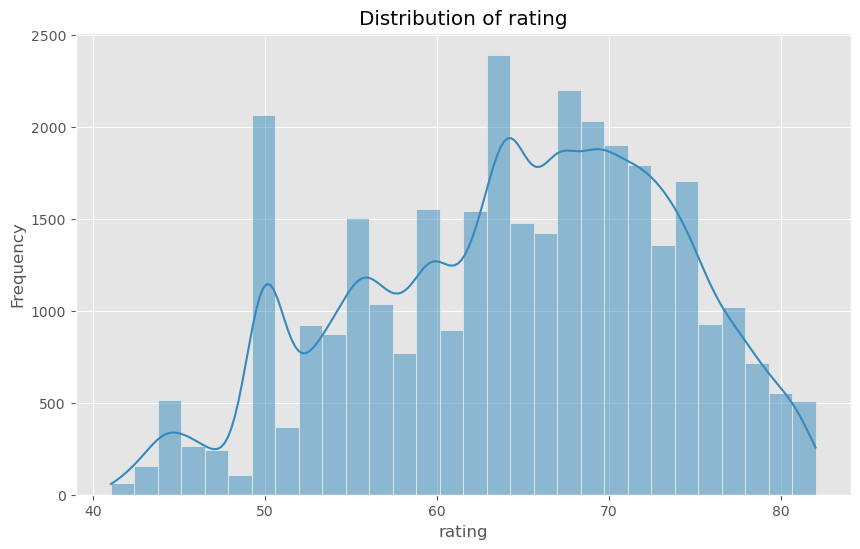

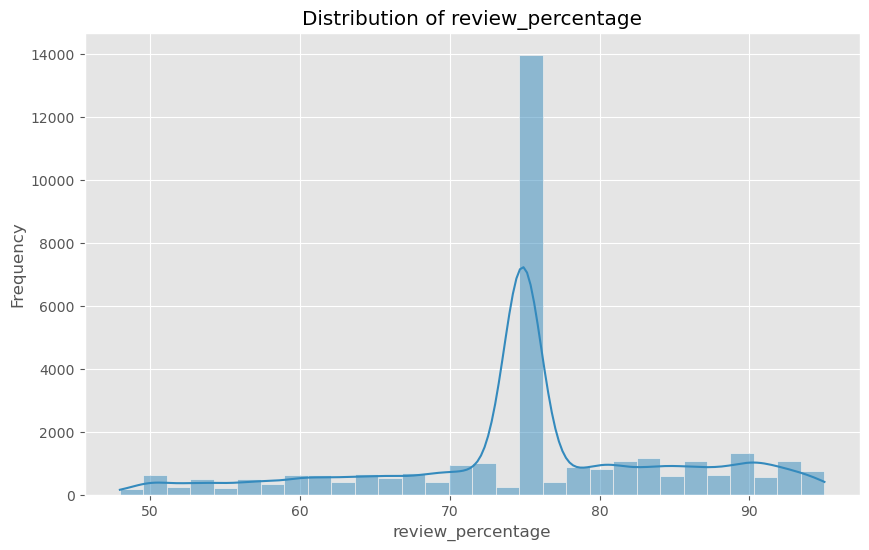

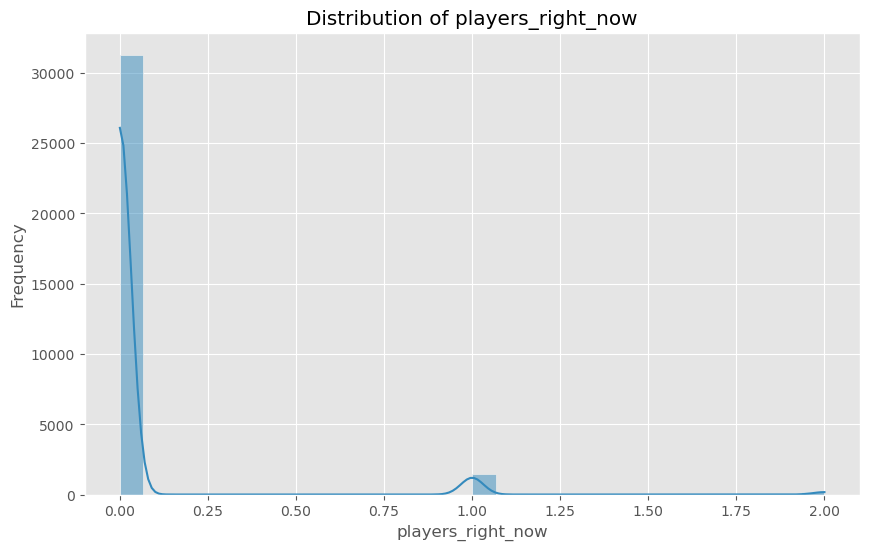

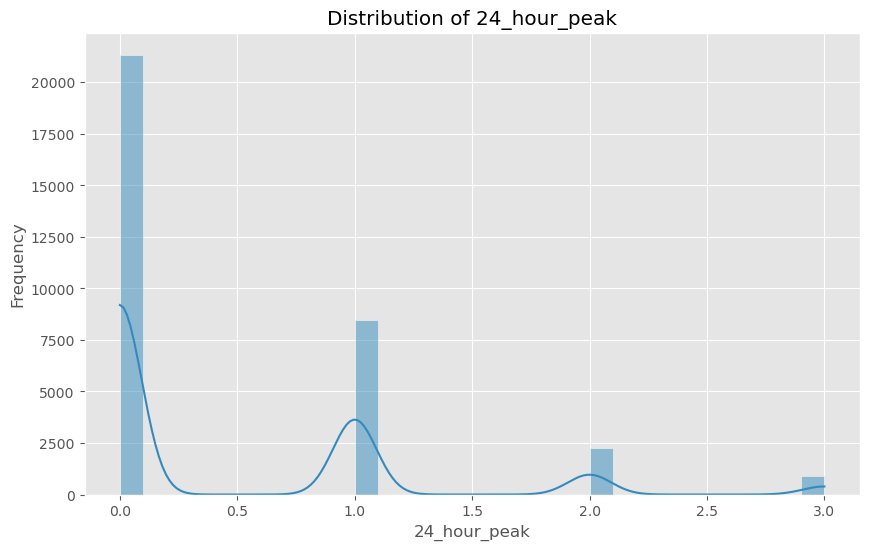

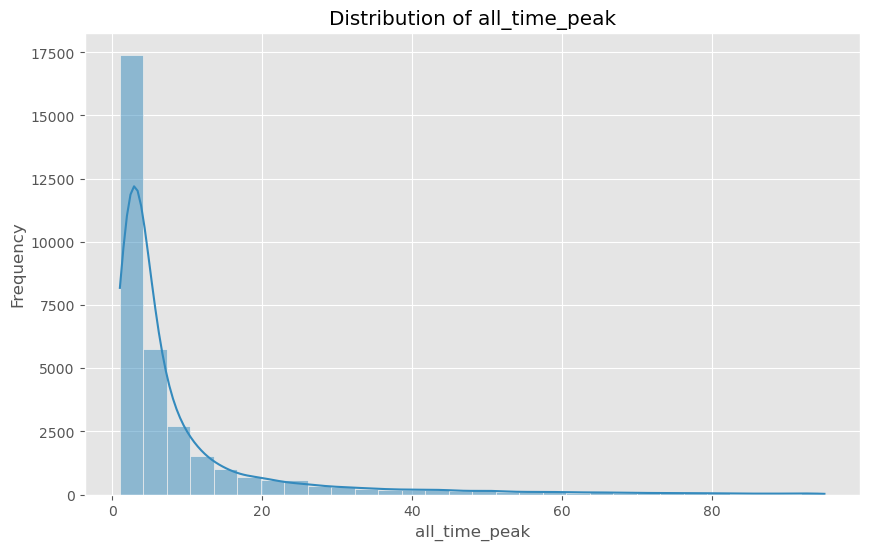

In [36]:
# Identifying numerical and categorical columns
numerical_columns = db.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = db.select_dtypes(include=['object', 'category']).columns.tolist()

# Plotting histograms for numerical columns
for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(db[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

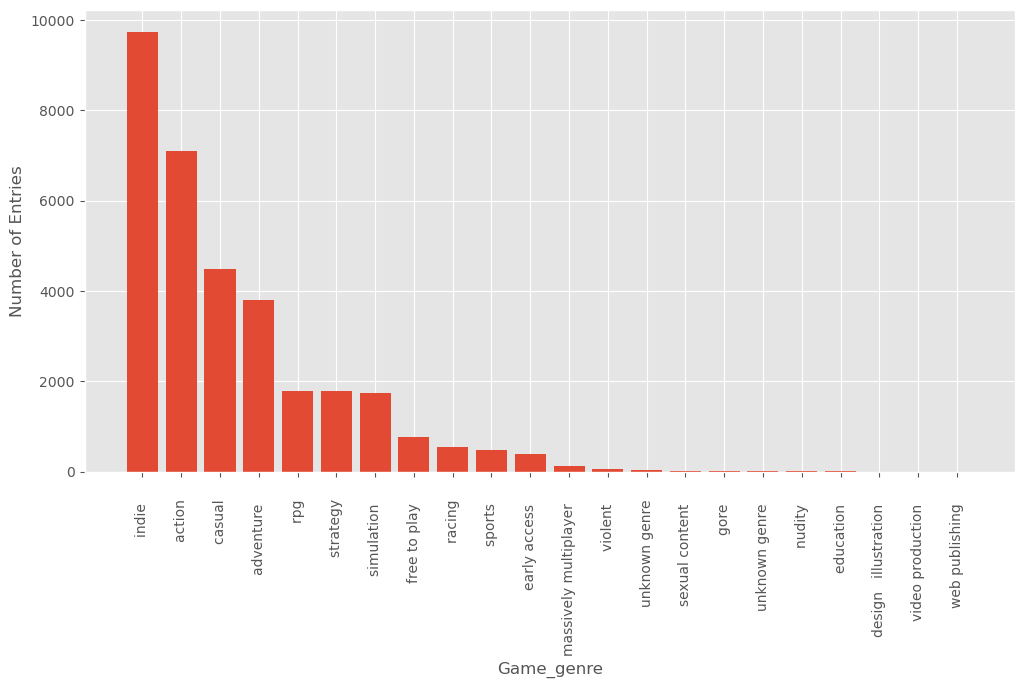

In [37]:
genre_entries = db['primary_genre'].value_counts()
plt.figure(figsize=(12, 6))
plt.bar(genre_entries.index, genre_entries.values)
plt.xlabel('Game_genre')
plt.ylabel('Number of Entries')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability plt.title('Distribution of Entries by Location')
plt.show()

### 3) Scatter Plot

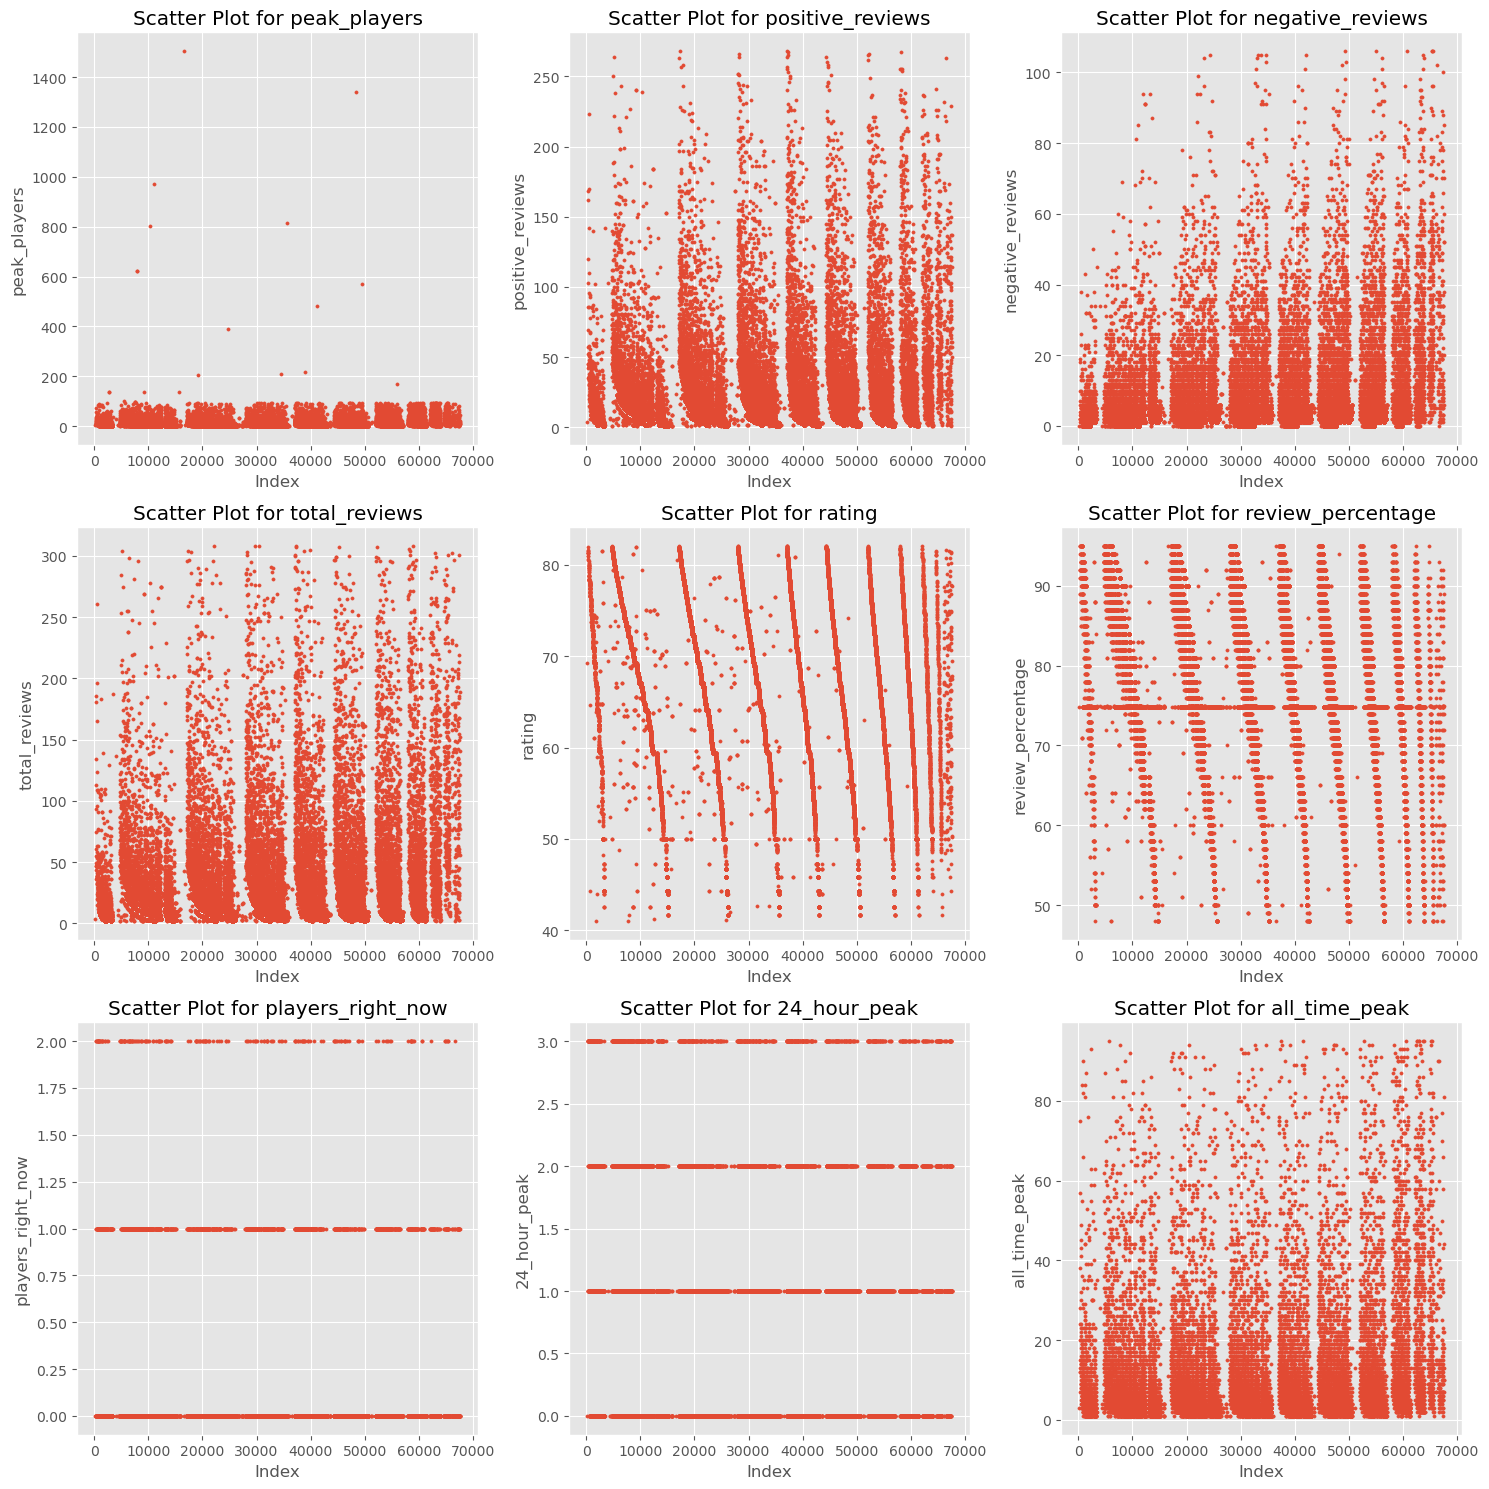

In [38]:
eda_copy = db.copy()
# Scatter plots for specified attributes
attributes_to_plot = ['peak_players', 'positive_reviews', 'negative_reviews', 'total_reviews', 'rating',
                       'review_percentage', 'players_right_now', '24_hour_peak', 'all_time_peak']
num_rows = (len(attributes_to_plot) - 1) // 3 + 1
num_cols = min(len(attributes_to_plot), 3)
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
axs = axs.flatten()
for i, attribute in enumerate(attributes_to_plot):
    axs[i].scatter(x=eda_copy.index, y=eda_copy[attribute],s=5)
    axs[i].set_title(f'Scatter Plot for {attribute}')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel(attribute)
plt.tight_layout()
plt.show()

### 4)Outliers Mapping

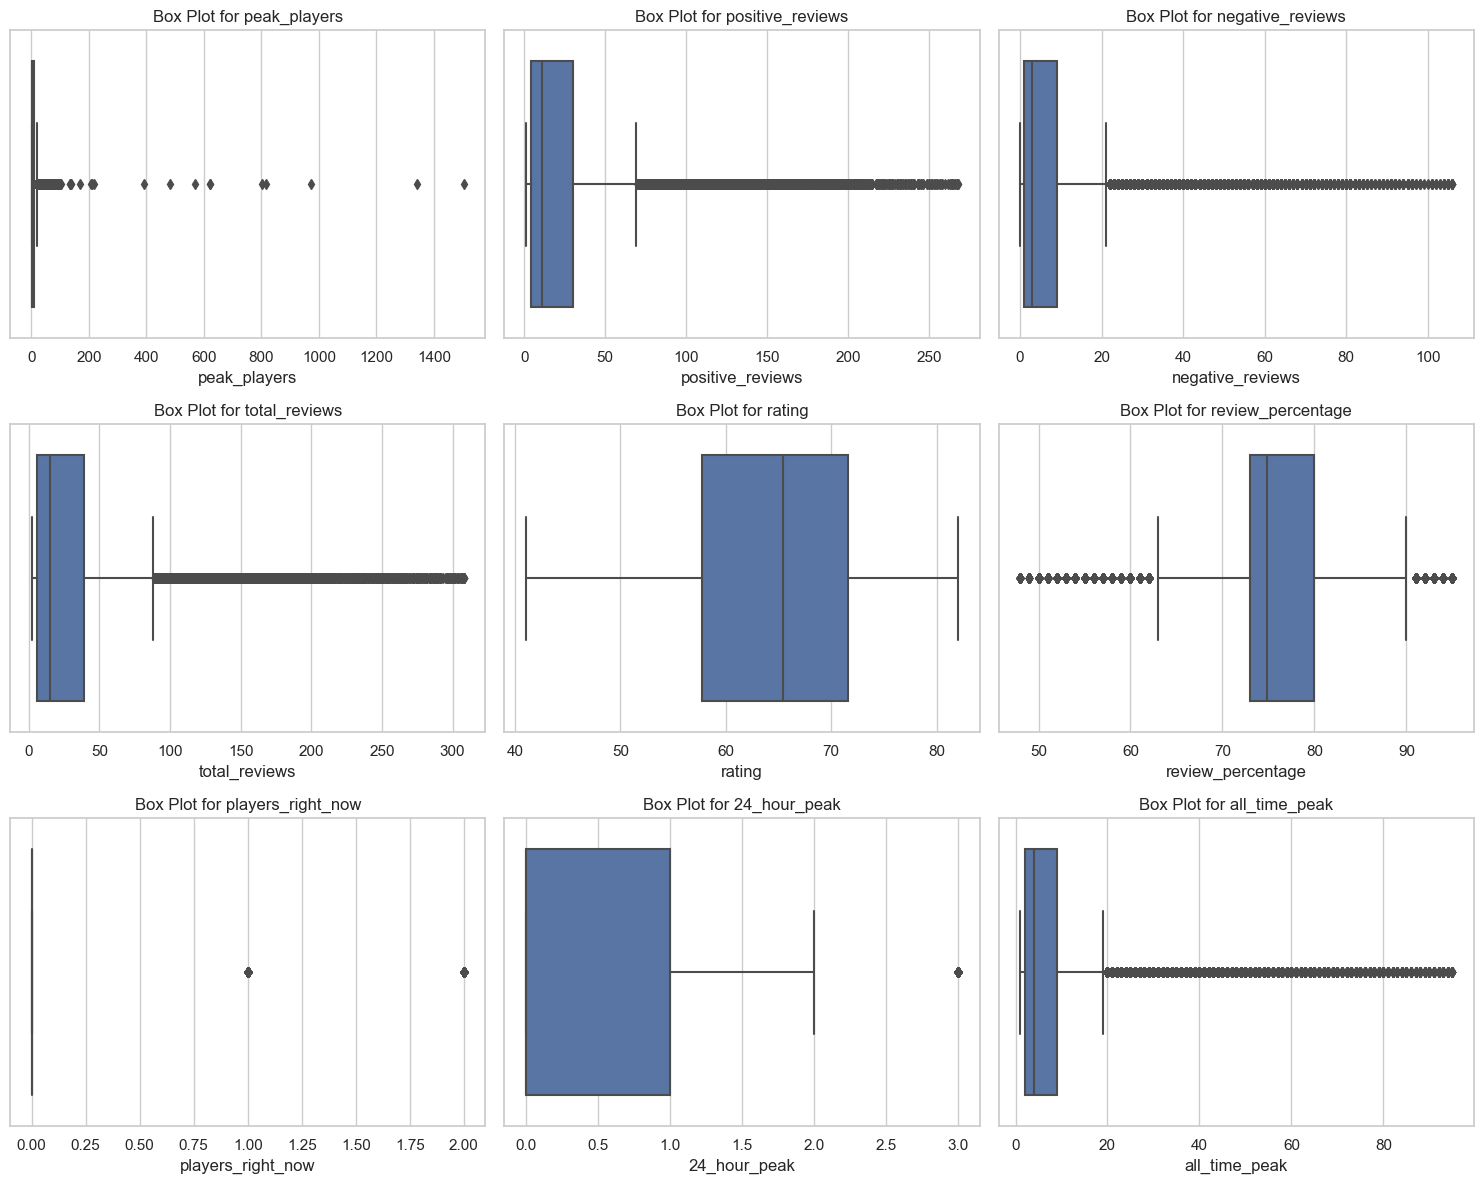

In [39]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
# Assuming 'eda_copy' is your DataFrame
eda_copy = db.copy()  # Make a copy to avoid modifying the original DataFrame

# Specify numerical columns for which you want to map outliers
numerical_columns = ['peak_players', 'positive_reviews', 'negative_reviews', 'total_reviews', 'rating',
                     'review_percentage', 'players_right_now', '24_hour_peak', 'all_time_peak']

# Create box plots to visualize outliers
plt.figure(figsize=(15, 12))
sns.set(style="whitegrid")

# Iterate through each numerical column and create box plots
for col in numerical_columns:
    plt.subplot(3, 3, numerical_columns.index(col) + 1)
    sns.boxplot(x=eda_copy[col], orient='v')
    plt.title(f'Box Plot for {col}')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


### 5)Bivariate analysis 

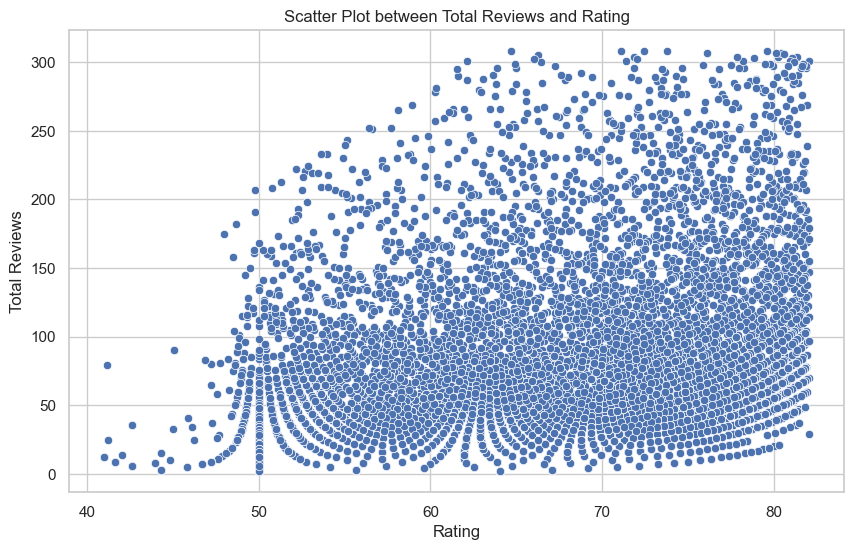

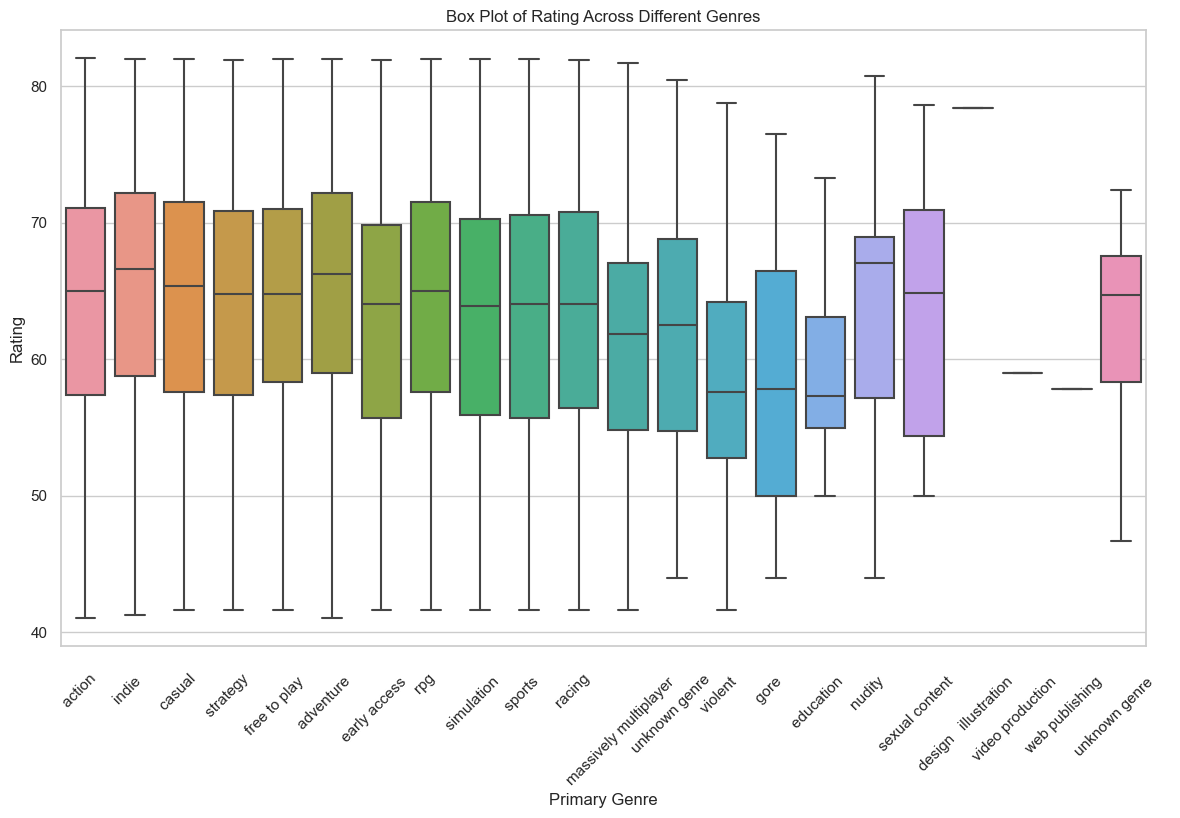

In [40]:

# Ensure the numerical columns are in the correct format
db['total_reviews'] = pd.to_numeric(db['total_reviews'], errors='coerce')
db['rating'] = pd.to_numeric(db['rating'], errors='coerce')

# Drop rows with NaN values for a clean plot
db = db.dropna(subset=['total_reviews', 'rating', 'primary_genre'])

# 1. Scatter Plot between 'total_reviews' and 'rating'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='rating', y='total_reviews', data=db)
plt.title('Scatter Plot between Total Reviews and Rating')
plt.xlabel('Rating')
plt.ylabel('Total Reviews')
plt.show()

# 2. Box Plot of 'rating' across different 'primary_genre'
plt.figure(figsize=(14, 8))
sns.boxplot(x='primary_genre', y='rating', data=db)
plt.title('Box Plot of Rating Across Different Genres')
plt.xlabel('Primary Genre')
plt.ylabel('Rating')
plt.xticks(rotation=45) 
plt.show()


### 6)statistical analysis of numerical variables

In [41]:
def plot_num(df, columns):
    num_plots = len(columns)
    num_rows = (num_plots // 2) + (num_plots % 2)

    fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows * 5))

    for i, column in enumerate(columns):
        row = i // 2
        col = i % 2
        ax = axes[row, col]

        sns.histplot(x=column, data=db, bins=30, kde=True, ax=ax)
        ax.axvline(df[column].mean(), color="r", linestyle="--", label="Mean")
        ax.axvline(df[column].median(), color="g", linestyle="-", label="Median")
        ax.grid()
        ax.set_title(f"{column} Distribution")
        ax.legend()

    plt.tight_layout()
    plt.show()


<Figure size 2000x2250 with 0 Axes>

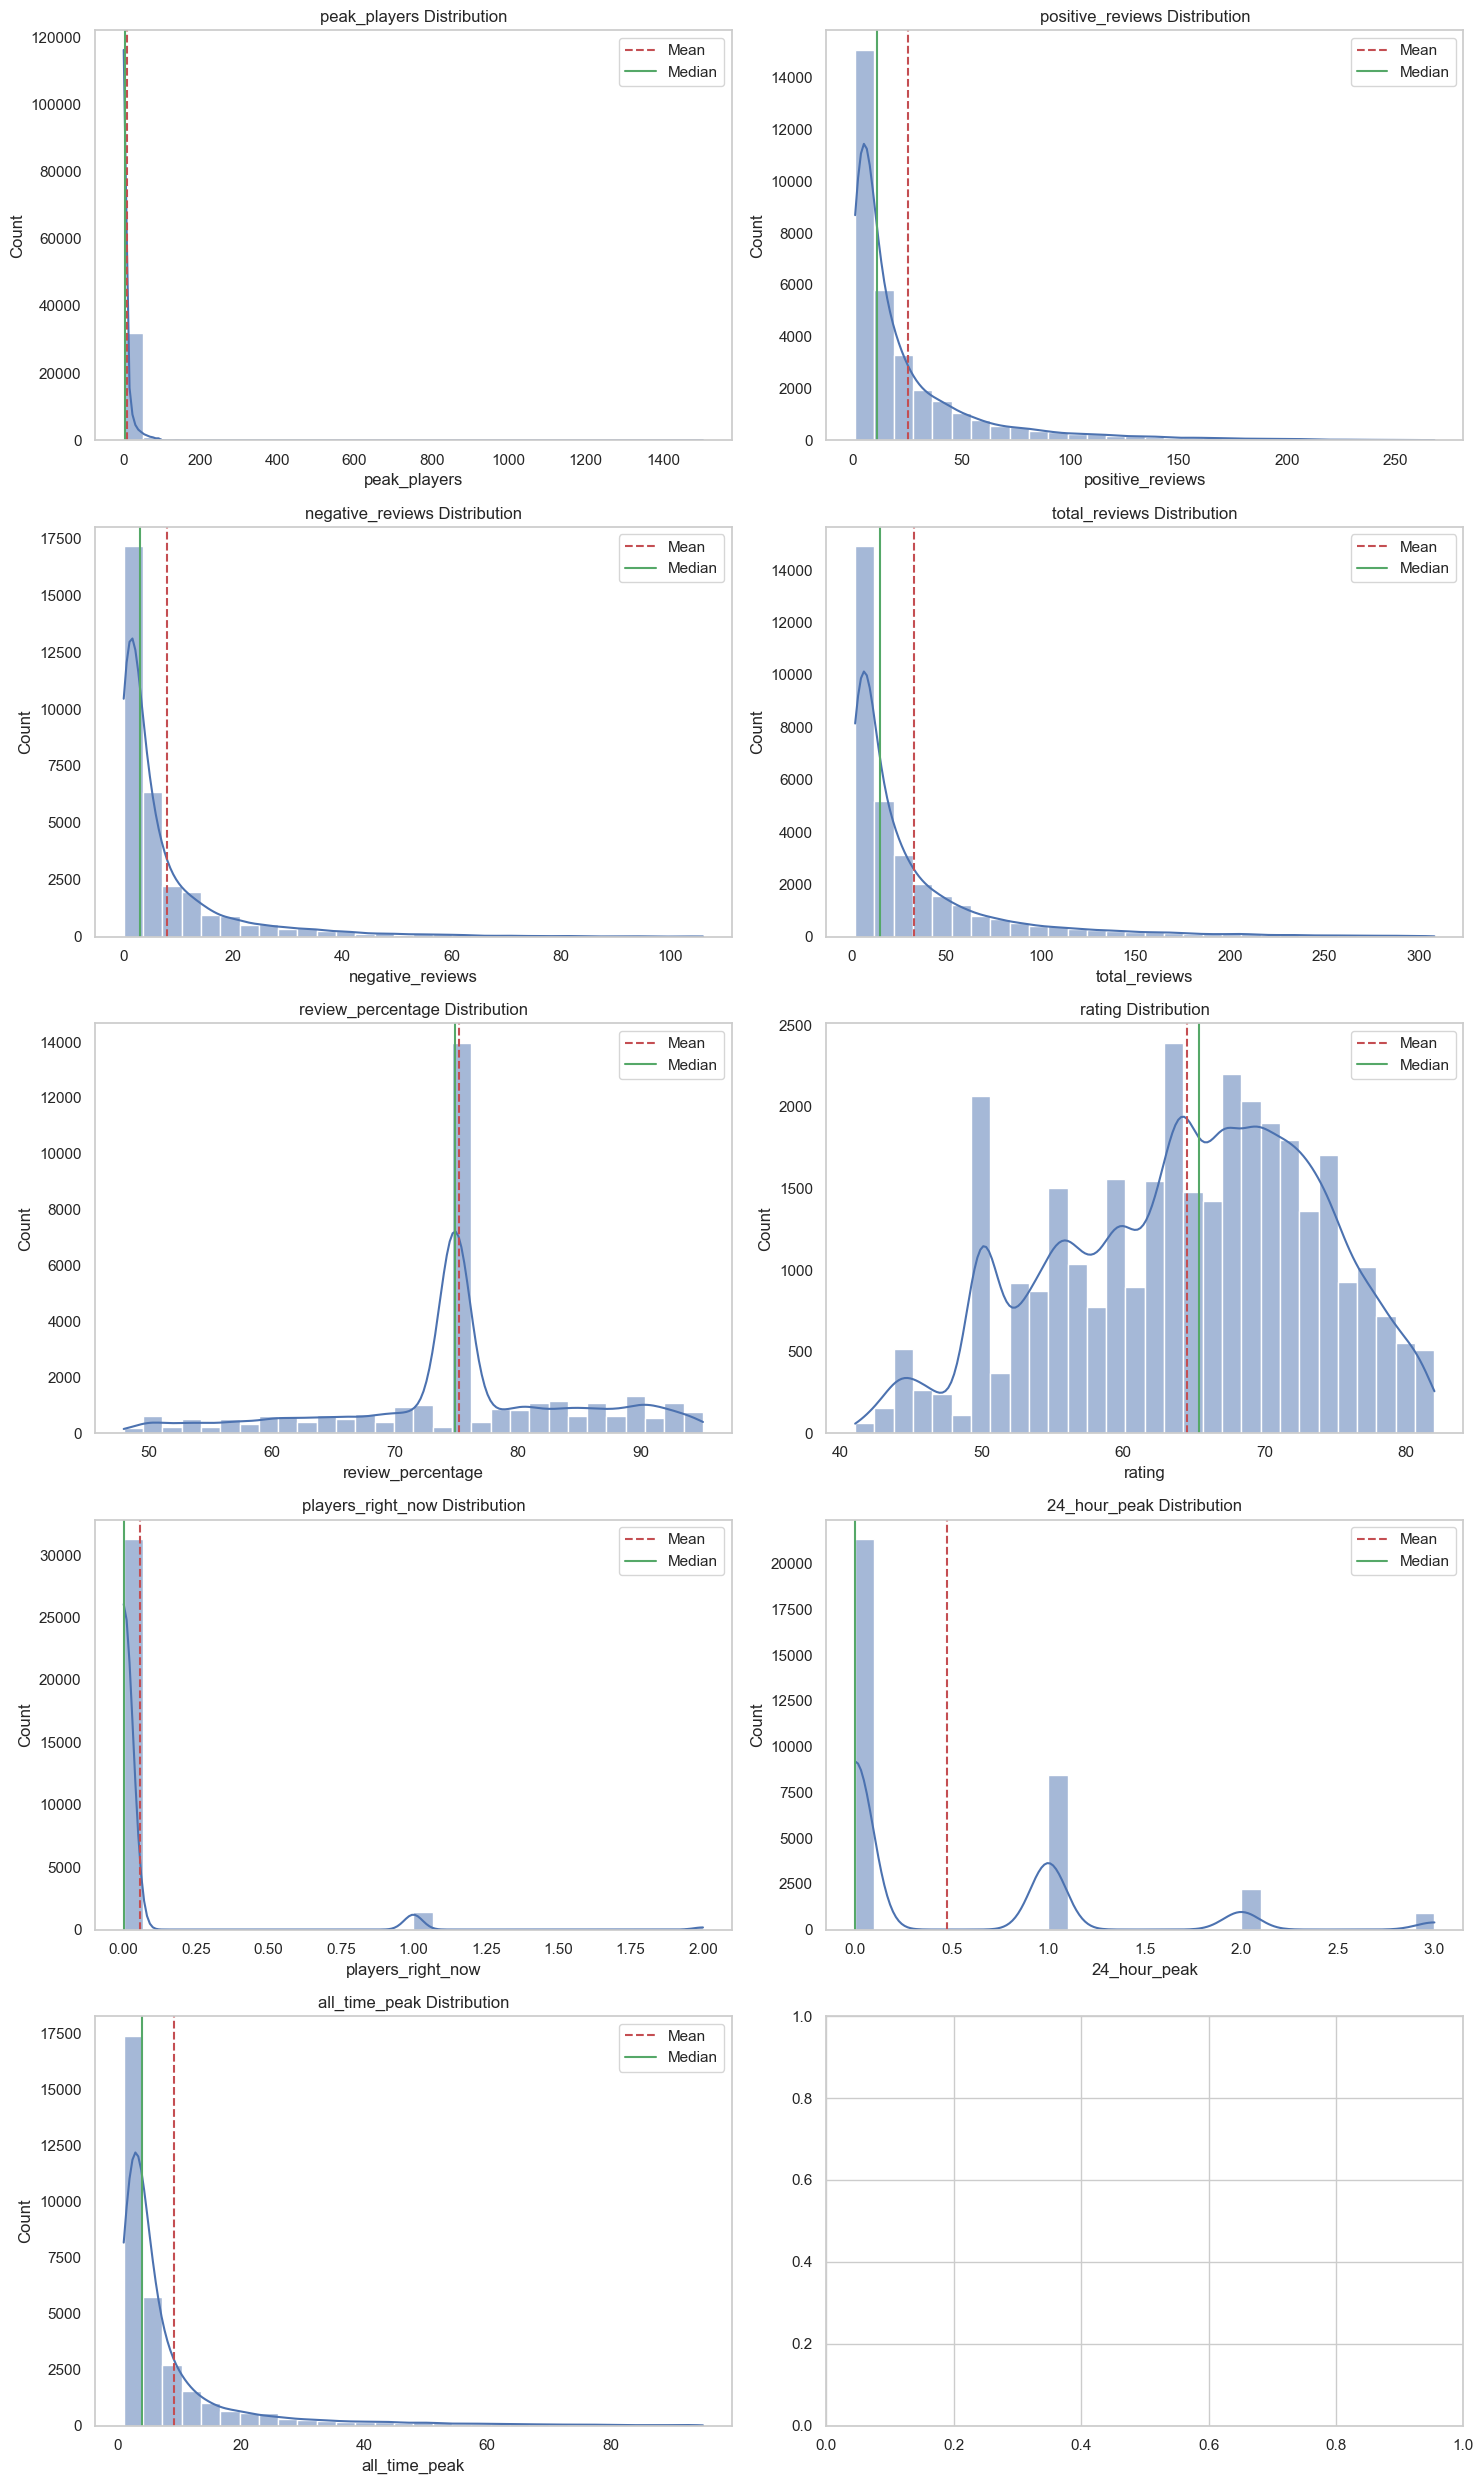

In [42]:
numerical_variables = ['peak_players', 'positive_reviews', 'negative_reviews',
                     'total_reviews', 'review_percentage', 'rating','players_right_now',
                     '24_hour_peak', 'all_time_peak']
plt.figure(figsize=(20, len(numerical_variables) * 2.5))
plot_num(db, numerical_variables)

### 7) Multivariate analysis

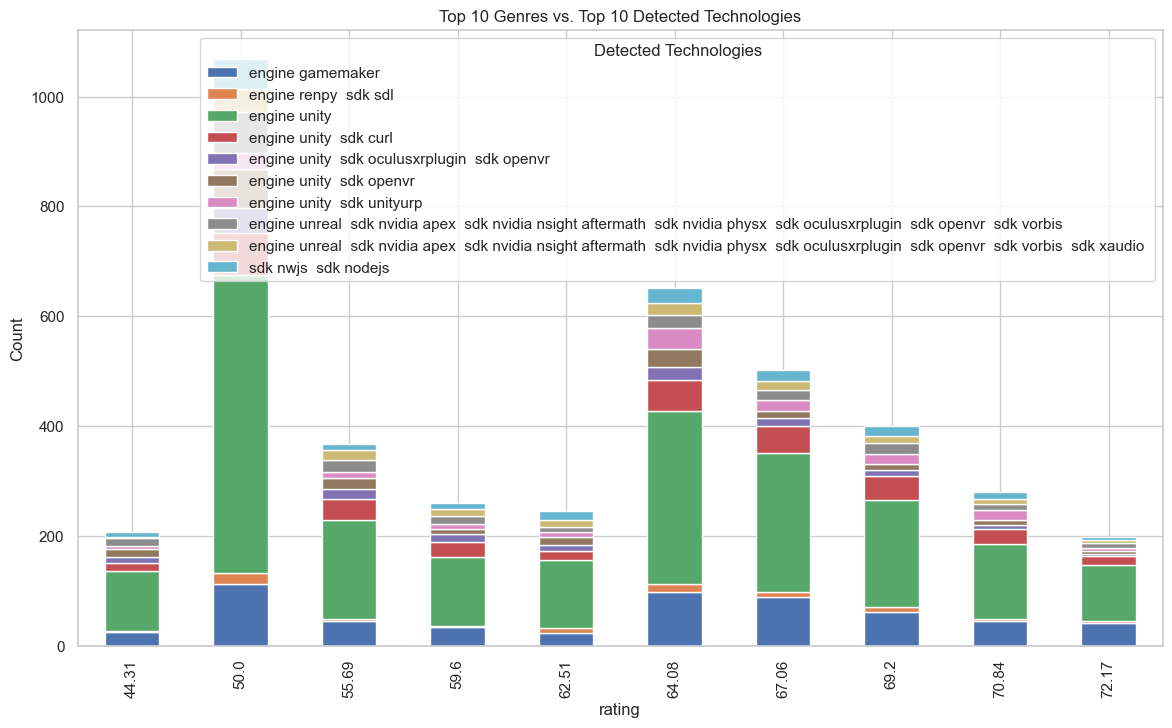

In [43]:
ead_copy = db.copy()

# Let's limit to top 10 genres and top 10 technologies for visualization
top_genres = ead_copy['rating'].value_counts().index[:10]
top_technologies = ead_copy['detected_technologies'].value_counts().index[:10]

# Filtering the data
filtered_data = ead_copy[ead_copy['rating'].isin(top_genres) & ead_copy['detected_technologies'].isin(top_technologies)]

# Creating a crosstab with the filtered data
cross_tab_df = pd.crosstab(filtered_data['rating'], filtered_data['detected_technologies'])

# Plotting
cross_tab_df.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Top 10 Genres vs. Top 10 Detected Technologies')
plt.xlabel('rating')
plt.ylabel('Count')
plt.legend(title='Detected Technologies')
plt.show()


### 8) Corelation matrix

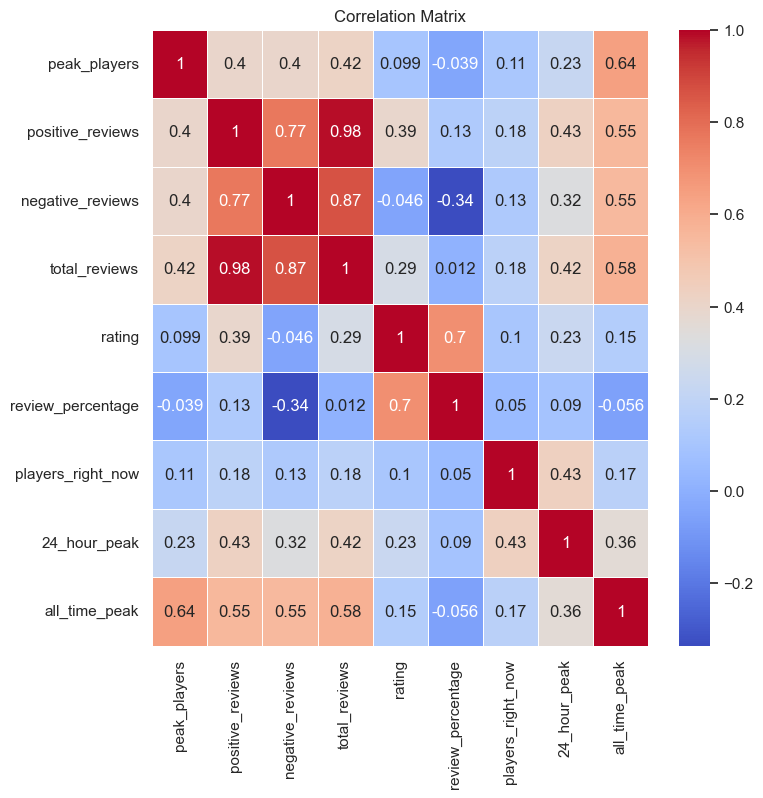

In [44]:
numerical_variables = ['peak_players', 'positive_reviews', 'negative_reviews',
                        'total_reviews', 'rating', 'review_percentage', 'players_right_now',
                        '24_hour_peak', 'all_time_peak']

# Extract the numerical variables from the DataFrame
correlation_data = db[numerical_variables]

# Create a correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix')
plt.show()


### 9) Standard Deviation and Mean Plots

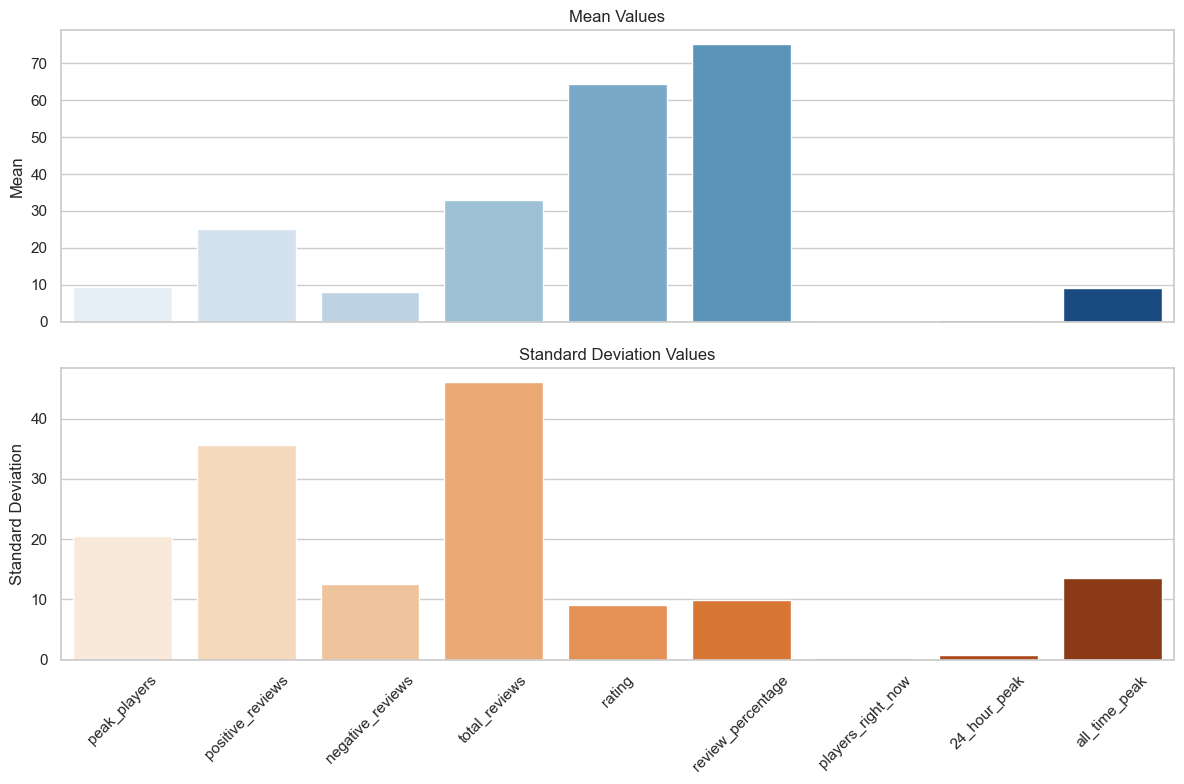

In [45]:
numerical_variables = ['peak_players', 'positive_reviews', 'negative_reviews',
                        'total_reviews', 'rating', 'review_percentage', 'players_right_now',
                        '24_hour_peak', 'all_time_peak']
numerical_data = db[numerical_variables]

# Calculate mean and standard deviation
mean_values = numerical_data.mean()
std_dev_values = numerical_data.std()

# Create a figure with two subplots (mean and standard deviation)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[0], palette='Blues')
axes[0].set_title('Mean Values')
axes[0].set_ylabel('Mean')

sns.barplot(x=std_dev_values.index, y=std_dev_values.values, ax=axes[1], palette='Oranges')
axes[1].set_title('Standard Deviation Values')
axes[1].set_ylabel('Standard Deviation')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 10) Corelation between rating and peak_players

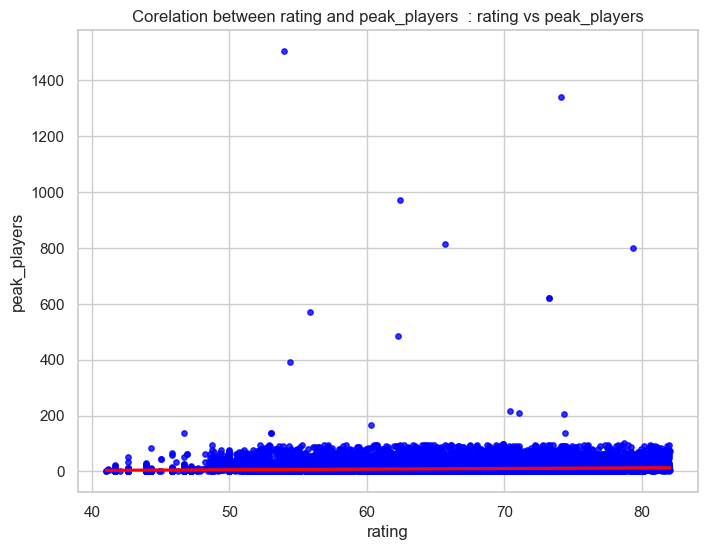

In [46]:
#initializing two variables
variable1 = 'rating'
variable2 = 'peak_players'
plt.figure(figsize=(8, 6))
sns.regplot(x=variable1, y=variable2, data=db, scatter_kws={'s': 15, 'color': 'blue'}, line_kws={'color': 'red'})
plt.title(f'Corelation between rating and peak_players  : {variable1} vs {variable2}')
plt.xlabel(variable1)
plt.ylabel(variable2)
plt.show()

### Gradient Boosting

In [47]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

numerical_columns = db_encoded.select_dtypes(include=['int64', 'float64']).columns
db_encoded[numerical_columns] = db_encoded[numerical_columns].apply(pd.to_numeric, errors='coerce')
db_encoded = db_encoded.dropna(subset=numerical_columns)

# splitting the dataset into features (X) and target variable (y)
X = db_encoded[numerical_columns].drop('rating', axis=1)
y = db_encoded['rating']
# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [48]:
X_test.columns


Index(['peak_players', 'positive_reviews', 'negative_reviews', 'total_reviews',
       'review_percentage', 'players_right_now', '24_hour_peak',
       'all_time_peak', 'engine gamemaker', 'engine renpy  sdk sdl',
       'engine unity', 'engine unity  sdk curl',
       'engine unity  sdk oculusxrplugin  sdk openvr',
       'engine unity  sdk openvr', 'engine unity  sdk photon',
       'engine unity  sdk steamworksnet  sdk curl',
       'engine unreal  sdk nvidia apex  sdk nvidia nsight aftermath  sdk nvidia physx  sdk oculusxrplugin  sdk openvr  sdk vorbis',
       'sdk nwjs  sdk nodejs'],
      dtype='object')

In [49]:

# initializing Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)

# training the model
gbr.fit(X_train, y_train)

# making predictions on test set
y_pred = gbr.predict(X_test)

# evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

Mean Absolute Error (MAE): 0.44682881669104657
Mean Squared Error (MSE): 1.0796833640130057
Root Mean Squared Error (RMSE): 1.0390781318134867
R-squared (R2): 0.9945871903837176


In [50]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(gbr, f)
